# Internship Data Analytics — 9-Tasks Notebook

RIDA FATIMA


In [15]:
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

BASE = "/kaggle/input/datasets/ridafati12"
PATHS = {
    "retail": f"{BASE}/retailsales/retail_sales_dataset.csv",
    "imdb": f"{BASE}/imdb-data/IMDB Dataset.csv",
    "house": f"{BASE}/house-pricing/train.csv",
    "wine": f"{BASE}/wine-quality/wine-quality-white-and-red.csv",
    "fraud": f"{BASE}/creditcard/creditcard.csv",
    "google": f"{BASE}/googlereviews/apps.csv",
    "corpus": f"{BASE}/english-corpus/Hindi_English_Truncated_Corpus.csv"
}

print("Dataset verification:")
for name, path in PATHS.items():
    print(f"{name:10s}:", "FOUND" if os.path.exists(path) else "MISSING")

Dataset verification:
retail    : FOUND
imdb      : FOUND
house     : FOUND
wine      : FOUND
fraud     : FOUND
google    : FOUND
corpus    : FOUND


## Level 1 — Task 1: Retail Sales Analysis

Shape: (1000, 9)
Columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



Missing values:


,Missing
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,41.392,13.681430,18.0,29.0,42.0,53.0,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0


,sum,mean,count
Product Category,,,
Electronics,156905,458.786550,342
Clothing,155580,443.247863,351
Beauty,143515,467.475570,307


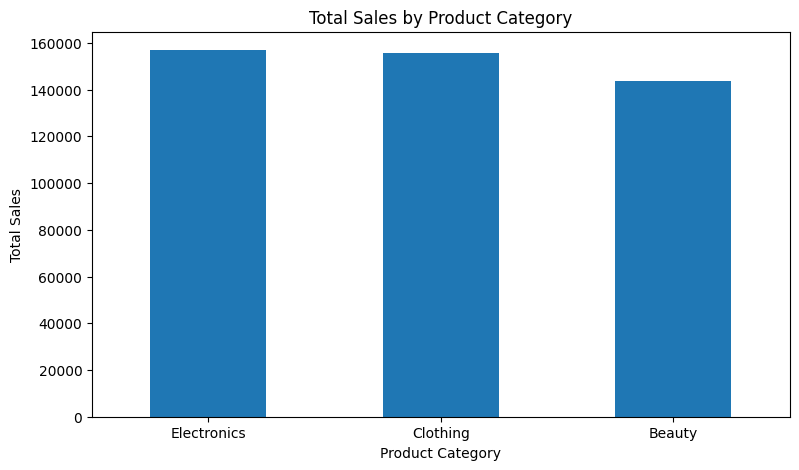

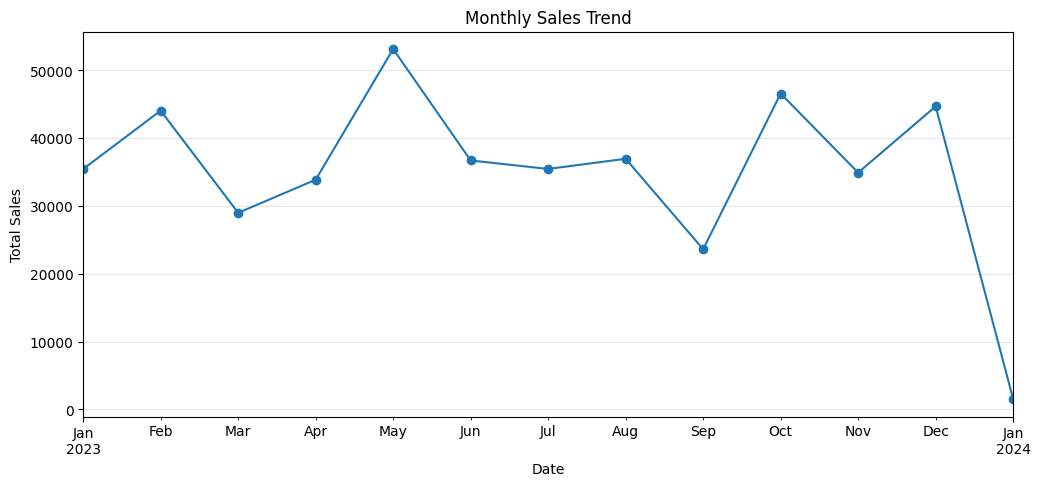

Total sales: 456000
Average transaction: 456.0
Customers: 1000
Best category: Electronics


In [16]:
retail = pd.read_csv(PATHS["retail"])
print("Shape:", retail.shape)
print("Columns:", retail.columns.tolist())
display(retail.head())

retail["Date"] = pd.to_datetime(retail["Date"], errors="coerce")
for col in ["Age", "Quantity", "Price per Unit", "Total Amount"]:
    retail[col] = pd.to_numeric(retail[col], errors="coerce")

print("\nMissing values:")
display(retail.isna().sum().to_frame("Missing"))
print("Duplicates:", retail.duplicated().sum())

retail = retail.dropna(
    subset=["Date", "Customer ID", "Product Category", "Quantity", "Total Amount"]
).copy()

display(retail[["Age","Quantity","Price per Unit","Total Amount"]].describe().T)

category_sales = retail.groupby("Product Category")["Total Amount"].agg(["sum","mean","count"]).sort_values("sum", ascending=False)
display(category_sales)

plt.figure(figsize=(9,5))
category_sales["sum"].plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

monthly_sales = retail.set_index("Date").resample("ME")["Total Amount"].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales")
plt.grid(True, alpha=.3)
plt.show()

print("Total sales:", round(retail["Total Amount"].sum(),2))
print("Average transaction:", round(retail["Total Amount"].mean(),2))
print("Customers:", retail["Customer ID"].nunique())
print("Best category:", category_sales["sum"].idxmax())

## Level 1 — Task 2: Customer Segmentation using RFM + K-Means

RFM shape: (1000, 4)


,Recency,Frequency,Monetary
count,1000.00,1000.0,1000.0
mean,182.98,1.0,456.0
std,105.28,0.0,560.0
min,1.00,1.0,25.0
25%,90.00,1.0,60.0
50%,186.50,1.0,135.0
75%,269.00,1.0,900.0
max,366.00,1.0,2000.0


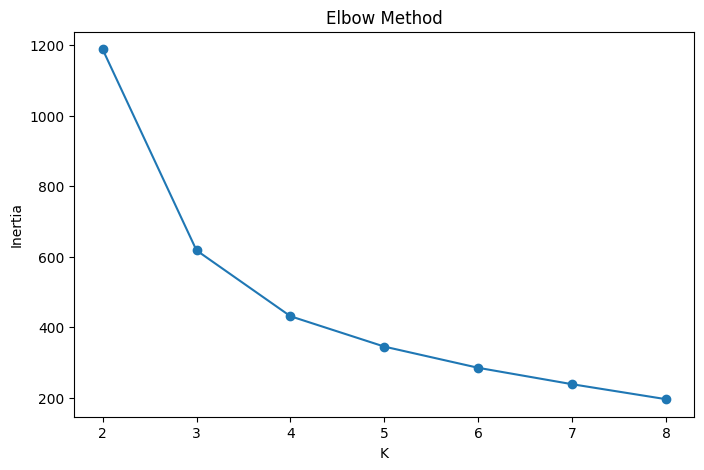

,Recency,Frequency,Monetary
Cluster,,,
0,270.52,1.0,1283.57
1,92.12,1.0,159.77
2,274.57,1.0,148.32
3,84.94,1.0,1313.71


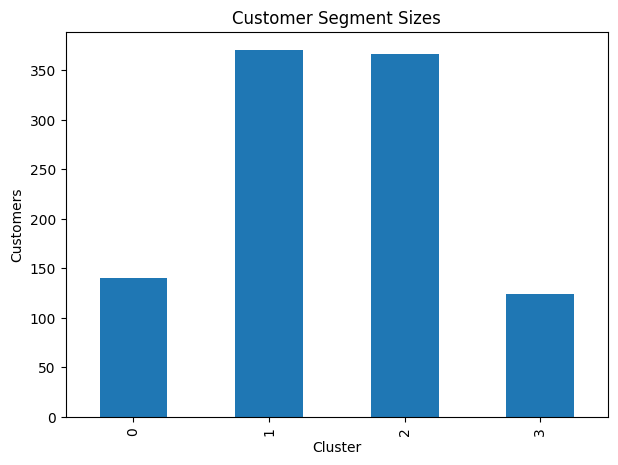


Marketing recommendations:
- High-frequency/high-monetary customers: loyalty/VIP retention.
- High-value customers with high recency: reactivation/retention.
- Recent but low-frequency customers: cross-sell and upsell.
- Low-value customers: low-cost promotions.



In [17]:
r = retail[retail["Total Amount"] > 0].copy()
reference_date = r["Date"].max() + pd.Timedelta(days=1)

rfm = r.groupby("Customer ID").agg(
    Recency=("Date", lambda x: (reference_date-x.max()).days),
    Frequency=("Transaction ID", "nunique"),
    Monetary=("Total Amount", "sum")
).reset_index()

print("RFM shape:", rfm.shape)
display(rfm.describe().round(2))

features = ["Recency","Frequency","Monetary"]
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm[features])

ks = range(2,9)
inertias = []
for k in ks:
    inertias.append(KMeans(n_clusters=k,n_init=10,random_state=42).fit(X_rfm).inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(ks), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

rfm["Cluster"] = KMeans(n_clusters=4,n_init=10,random_state=42).fit_predict(X_rfm)
display(rfm.groupby("Cluster")[features].mean().round(2))

plt.figure(figsize=(7,5))
rfm["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Customer Segment Sizes")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.show()

print("""
Marketing recommendations:
- High-frequency/high-monetary customers: loyalty/VIP retention.
- High-value customers with high recency: reactivation/retention.
- Recent but low-frequency customers: cross-sell and upsell.
- Low-value customers: low-cost promotions.
""")

## Level 1 — Task 3: Retail Customer and Product Insights

Top customers:


,Total Spending
Customer ID,
CUST946,2000
CUST626,2000
CUST634,2000
CUST773,2000
CUST420,2000
CUST416,2000
CUST743,2000
CUST742,2000
CUST595,2000


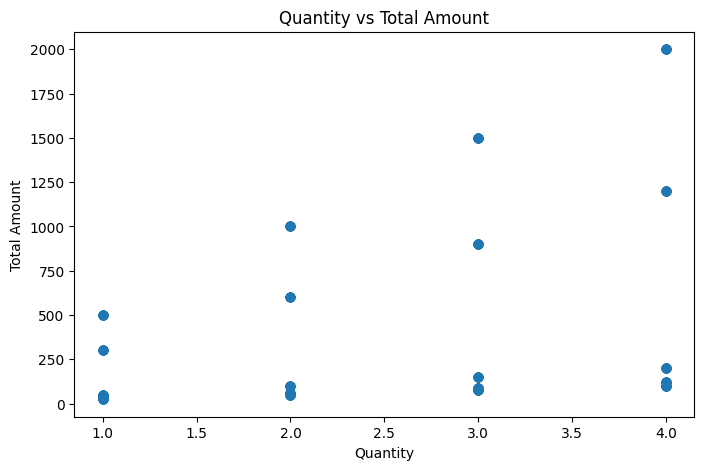

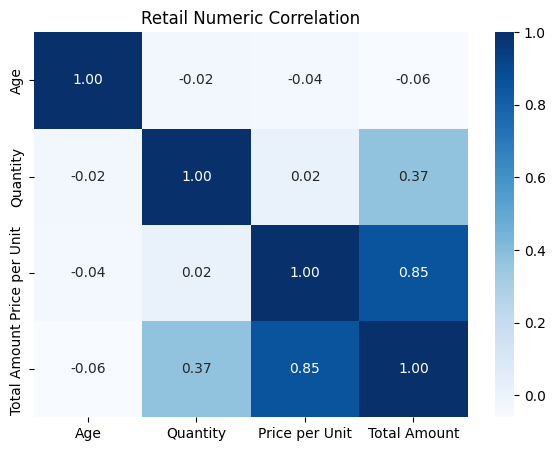

In [18]:
customer_sales = retail.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False)
print("Top customers:")
display(customer_sales.head(10).to_frame("Total Spending"))

plt.figure(figsize=(8,5))
plt.scatter(retail["Quantity"], retail["Total Amount"], alpha=.5)
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

corr_cols = ["Age","Quantity","Price per Unit","Total Amount"]
plt.figure(figsize=(7,5))
sns.heatmap(retail[corr_cols].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Retail Numeric Correlation")
plt.show()

## Level 1 — Task 4: IMDB Sentiment Analysis

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

 Naive Bayes
              precision    recall  f1-score   support

    negative       0.88      0.88      0.88      5000
    positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


 Logistic Regression
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.8806,0.8806,0.8806,0.8806
1,Logistic Regression,0.9016,0.9018,0.9016,0.9016


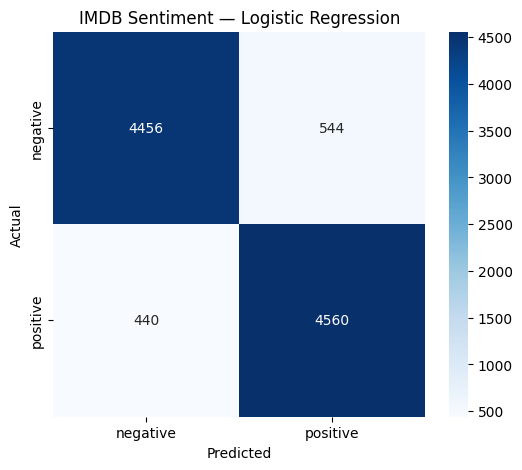

In [19]:
imdb = pd.read_csv(PATHS["imdb"])
print("Shape:", imdb.shape)
display(imdb.head())
print(imdb["sentiment"].value_counts())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

imdb["clean_review"] = imdb["review"].map(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    imdb["clean_review"], imdb["sentiment"],
    test_size=.20, stratify=imdb["sentiment"], random_state=42
)

vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1,2),
    min_df=2, max_features=100000
)
A = vectorizer.fit_transform(X_train)
B = vectorizer.transform(X_test)

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1500)
}

rows = []
predictions = {}

for name, model in models.items():
    model.fit(A, y_train)
    pred = model.predict(B)
    predictions[name] = pred
    rows.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred,average="macro",zero_division=0),
        recall_score(y_test,pred,average="macro",zero_division=0),
        f1_score(y_test,pred,average="macro",zero_division=0)
    ])
    print("\n", name)
    print(classification_report(y_test,pred,zero_division=0))

sentiment_results = pd.DataFrame(rows, columns=["Model","Accuracy","Precision","Recall","F1"])
display(sentiment_results.round(4))

cm = confusion_matrix(y_test, predictions["Logistic Regression"], labels=["negative","positive"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative","positive"], yticklabels=["negative","positive"])
plt.title("IMDB Sentiment — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Level 2 — Task 1: House Price Prediction

In [20]:
house = pd.read_csv(PATHS["house"])
print("Shape:", house.shape)
print("Target: SalePrice")
display(house.head())

X = house.drop(columns=["SalePrice"]).copy()
y = house["SalePrice"].copy()
if "Id" in X.columns:
    X = X.drop(columns=["Id"])

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.20,random_state=42)

models = {
    "Linear Regression": Pipeline([
        ("preprocessor",preprocessor),("model",LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("preprocessor",preprocessor),
        ("model",RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1))
    ])
}

house_rows = []
for name, model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    house_rows.append([
        name,
        mean_absolute_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred)),
        r2_score(y_test,pred)
    ])

house_results = pd.DataFrame(house_rows,columns=["Model","MAE","RMSE","R2"])
display(house_results.round(3))

Shape: (1460, 81)
Target: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Model,MAE,RMSE,R2
0,Linear Regression,20470.605,31293.388,0.872
1,Random Forest,17386.106,28495.231,0.894


## Level 2 — Task 2: Wine Quality Prediction

In [21]:
wine = pd.read_csv(PATHS["wine"])
print("Shape:", wine.shape)
print(wine.columns.tolist())
display(wine.head())

wine_model = wine.copy()
wine_model["type"] = wine_model["type"].astype(str)
wine_model["good_quality"] = (wine_model["quality"] >= 7).astype(int)

X = wine_model.drop(columns=["quality","good_quality"])
y = wine_model["good_quality"]
X = pd.get_dummies(X, columns=["type"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=.20,stratify=y,random_state=42
)

scaler = StandardScaler()
A = scaler.fit_transform(X_train)
B = scaler.transform(X_test)

wine_lr = LogisticRegression(max_iter=2000,class_weight="balanced")
wine_lr.fit(A,y_train)
p_lr = wine_lr.predict(B)

wine_rf = RandomForestClassifier(
    n_estimators=250,random_state=42,n_jobs=-1,class_weight="balanced"
)
wine_rf.fit(X_train,y_train)
p_rf = wine_rf.predict(X_test)

wine_results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,p_lr),accuracy_score(y_test,p_rf)],
    "Precision":[precision_score(y_test,p_lr,zero_division=0),precision_score(y_test,p_rf,zero_division=0)],
    "Recall":[recall_score(y_test,p_lr,zero_division=0),recall_score(y_test,p_rf,zero_division=0)],
    "F1":[f1_score(y_test,p_lr,zero_division=0),f1_score(y_test,p_rf,zero_division=0)],
    "ROC-AUC":[roc_auc_score(y_test,wine_lr.predict_proba(B)[:,1]),roc_auc_score(y_test,wine_rf.predict_proba(X_test)[:,1])]
})
display(wine_results.round(4))

Shape: (6497, 13)
['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7185,0.3917,0.7773,0.5209,0.8146
1,Random Forest,0.8923,0.8537,0.5469,0.6667,0.9328


## Level 2 — Task 3: Credit Card Fraud Detection

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Count
Class,
0,284315
1,492


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.0610,0.9184,0.1144,0.9721
1,Random Forest,0.9605,0.7449,0.8391,0.9474


Random Forest classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



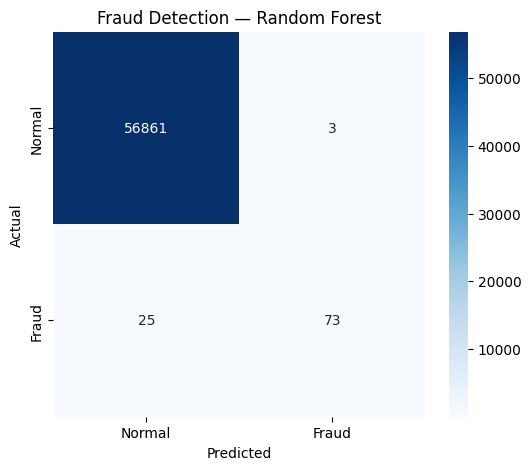

In [22]:
fraud = pd.read_csv(PATHS["fraud"])
print("Shape:", fraud.shape)
display(fraud.head())
display(fraud["Class"].value_counts().to_frame("Count"))

X = fraud.drop(columns=["Class"])
y = fraud["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=.20,stratify=y,random_state=42
)

fraud_lr = Pipeline([
    ("scaler",StandardScaler()),
    ("model",LogisticRegression(max_iter=2000,class_weight="balanced"))
])
fraud_lr.fit(X_train,y_train)
p_lr = fraud_lr.predict(X_test)
prob_lr = fraud_lr.predict_proba(X_test)[:,1]

fraud_rf = RandomForestClassifier(
    n_estimators=150,random_state=42,n_jobs=-1,
    class_weight="balanced_subsample"
)
fraud_rf.fit(X_train,y_train)
p_rf = fraud_rf.predict(X_test)
prob_rf = fraud_rf.predict_proba(X_test)[:,1]

fraud_results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Precision":[precision_score(y_test,p_lr,zero_division=0),precision_score(y_test,p_rf,zero_division=0)],
    "Recall":[recall_score(y_test,p_lr,zero_division=0),recall_score(y_test,p_rf,zero_division=0)],
    "F1":[f1_score(y_test,p_lr,zero_division=0),f1_score(y_test,p_rf,zero_division=0)],
    "ROC-AUC":[roc_auc_score(y_test,prob_lr),roc_auc_score(y_test,prob_rf)]
})
display(fraud_results.round(4))

print("Random Forest classification report:")
print(classification_report(y_test,p_rf,zero_division=0))

cm = confusion_matrix(y_test,p_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Normal","Fraud"],yticklabels=["Normal","Fraud"])
plt.title("Fraud Detection — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Level 2 — Task 4: Google Play Store Analysis

Shape: (9659, 14)
Columns: ['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


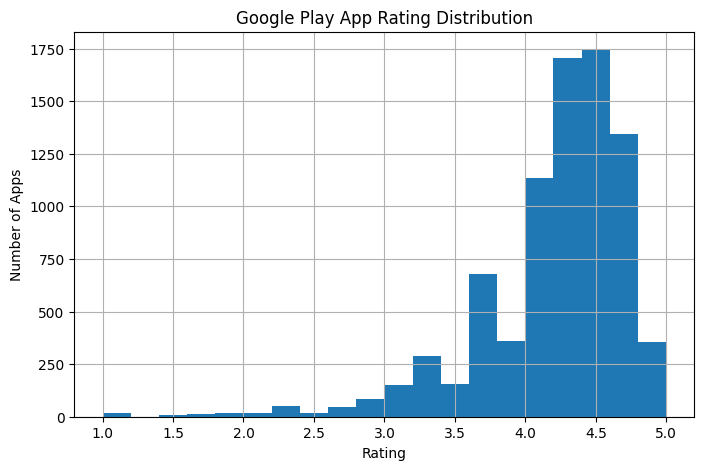

,Number of Apps
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


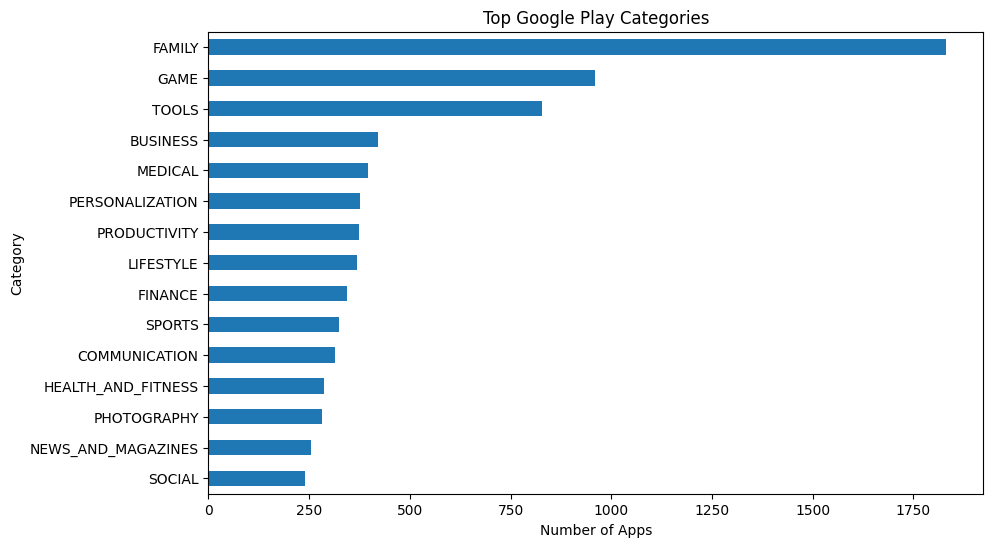

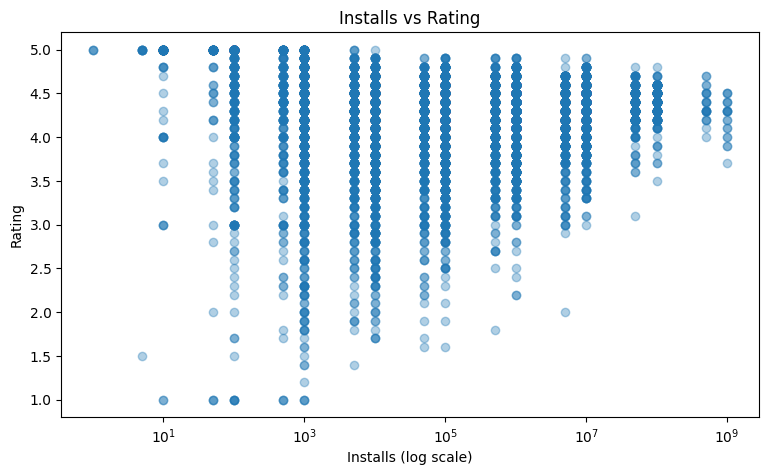

,App,Category,Rating,Reviews,Installs_num
2002,Facebook,SOCIAL,4.1,78158306,1000000000
300,WhatsApp Messenger,COMMUNICATION,4.4,69119316,1000000000
2003,Instagram,SOCIAL,4.5,66577313,1000000000
299,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,1000000000
1372,Clash of Clans,GAME,4.6,44891723,100000000
3181,Clean Master- Space Cleaner & Antivirus,TOOLS,4.7,42916526,500000000
1356,Subway Surfers,GAME,4.5,27722264,1000000000
2908,YouTube,VIDEO_PLAYERS,4.3,25655305,1000000000
6486,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999,500000000
1362,Clash Royale,GAME,4.6,23133508,100000000



Dataset limitation:
apps.csv contains app-level information but no individual review text
or sentiment labels. Therefore review sentiment cannot be validly
calculated from this file alone.



In [23]:
apps = pd.read_csv(PATHS["google"])
print("Shape:", apps.shape)
print("Columns:", apps.columns.tolist())
display(apps.head())

apps["Rating"] = pd.to_numeric(apps["Rating"],errors="coerce")
apps["Reviews"] = pd.to_numeric(apps["Reviews"],errors="coerce")
apps["Installs_num"] = pd.to_numeric(
    apps["Installs"].astype(str).str.replace(",","",regex=False).str.replace("+","",regex=False),
    errors="coerce"
)
apps["Price_num"] = pd.to_numeric(
    apps["Price"].astype(str).str.replace("$","",regex=False),
    errors="coerce"
)

plt.figure(figsize=(8,5))
apps["Rating"].dropna().hist(bins=20)
plt.title("Google Play App Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

category_counts = apps["Category"].value_counts().head(15)
display(category_counts.to_frame("Number of Apps"))

plt.figure(figsize=(10,6))
category_counts.sort_values().plot(kind="barh")
plt.title("Top Google Play Categories")
plt.xlabel("Number of Apps")
plt.show()

plot_data = apps.dropna(subset=["Rating","Installs_num"])
plt.figure(figsize=(9,5))
plt.scatter(plot_data["Installs_num"],plot_data["Rating"],alpha=.35)
plt.xscale("log")
plt.title("Installs vs Rating")
plt.xlabel("Installs (log scale)")
plt.ylabel("Rating")
plt.show()

top_reviewed = apps[["App","Category","Rating","Reviews","Installs_num"]].dropna(subset=["Reviews"]).sort_values("Reviews",ascending=False).head(10)
display(top_reviewed)

print("""
Dataset limitation:
apps.csv contains app-level information but no individual review text
or sentiment labels. Therefore review sentiment cannot be validly
calculated from this file alone.
""")

## Level 2 — Task 5: English Autocomplete and Autocorrect

In [24]:
corpus = pd.read_csv(PATHS["corpus"])
print("Shape:", corpus.shape)
print(corpus.columns.tolist())
display(corpus.head())

sentences = corpus["english_sentence"].dropna().astype(str)
sentences = sentences[sentences.str.strip().ne("")].tolist()

text = " ".join(sentences).lower()
words = re.findall(r"[a-z]+(?:'[a-z]+)?",text)

print("Sentences:",len(sentences))
print("Words:",len(words))
print("Unique words:",len(set(words)))

bigram = defaultdict(Counter)
trigram = defaultdict(Counter)

for i in range(len(words)-1):
    bigram[words[i]][words[i+1]] += 1

for i in range(len(words)-2):
    trigram[(words[i],words[i+1])][words[i+2]] += 1

def autocomplete(prefix, top_n=5):
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?",prefix.lower())
    if not tokens:
        return []
    if len(tokens) >= 2 and trigram.get((tokens[-2],tokens[-1])):
        return trigram[(tokens[-2],tokens[-1])].most_common(top_n)
    return bigram.get(tokens[-1],Counter()).most_common(top_n)

for phrase in ["i would","the government","we need","this is","people are"]:
    print("\nInput:",phrase)
    print("Suggestions:",autocomplete(phrase))

word_counts = Counter(words)
vocabulary = [w for w,c in word_counts.items() if len(w)>=2 and c>=2]

def edit_distance(a,b):
    previous = list(range(len(b)+1))
    for i,ca in enumerate(a,1):
        current=[i]
        for j,cb in enumerate(b,1):
            current.append(min(
                current[j-1]+1,
                previous[j]+1,
                previous[j-1]+(ca!=cb)
            ))
        previous=current
    return previous[-1]

def autocorrect(word,max_candidates=8):
    word=word.lower().strip()
    if not word:
        return []
    if word in word_counts:
        return [(word,word_counts[word],0)]
    candidates=[w for w in vocabulary if abs(len(w)-len(word))<=2]
    scored=[]
    for candidate in candidates:
        d=edit_distance(word,candidate)
        if d<=2:
            scored.append((candidate,word_counts[candidate],d))
    scored.sort(key=lambda x:(x[2],-x[1]))
    return scored[:max_candidates]

for word in ["goverment","becuase","recieve","diffrent","enviroment"]:
    print("\nMisspelled:",word)
    print("Suggestions:",autocorrect(word))

Shape: (127607, 3)
['source', 'english_sentence', 'hindi_sentence']


,source,english_sentence,hindi_sentence
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,ted,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,indic2012,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


Sentences: 127605
Words: 1929857
Unique words: 61377

Input: i would
Suggestions: [('like', 31), ('have', 18), ('say', 11), ('not', 9), ('go', 9)]

Input: the government
Suggestions: [('of', 159), ('and', 56), ('to', 48), ('s', 46), ('is', 41)]

Input: we need
Suggestions: [('to', 107), ('a', 8), ('the', 5), ('more', 4), ('an', 4)]

Input: this is
Suggestions: [('the', 310), ('a', 280), ('not', 105), ('what', 74), ('an', 62)]

Input: people are
Suggestions: [('not', 7), ('getting', 3), ('more', 3), ('being', 3), ('living', 3)]

Misspelled: goverment
Suggestions: [('goverment', 11, 0)]

Misspelled: becuase
Suggestions: [('becuase', 2, 0)]

Misspelled: recieve
Suggestions: [('relieve', 11, 1), ('recieved', 6, 1), ('believe', 499, 2), ('receive', 116, 2), ('relieved', 26, 2), ('recite', 23, 2), ('revive', 17, 2), ('recipe', 8, 2)]

Misspelled: diffrent
Suggestions: [('diffrent', 15, 0)]

Misspelled: enviroment
Suggestions: [('environment', 318, 1), ('environments', 32, 2)]


## Final Summary and Save Outputs

In [25]:
OUTPUT_DIR = "/kaggle/working/internship_outputs"
os.makedirs(OUTPUT_DIR,exist_ok=True)

retail.to_csv(f"{OUTPUT_DIR}/cleaned_retail.csv",index=False)
rfm.to_csv(f"{OUTPUT_DIR}/customer_rfm_segments.csv",index=False)
sentiment_results.to_csv(f"{OUTPUT_DIR}/sentiment_model_comparison.csv",index=False)
house_results.to_csv(f"{OUTPUT_DIR}/house_model_comparison.csv",index=False)
wine_results.to_csv(f"{OUTPUT_DIR}/wine_model_comparison.csv",index=False)
fraud_results.to_csv(f"{OUTPUT_DIR}/fraud_model_comparison.csv",index=False)
top_reviewed.to_csv(f"{OUTPUT_DIR}/top_google_apps.csv",index=False)

summary = pd.DataFrame({
    "Task":[
        "Level 1 Task 1","Level 1 Task 2","Level 1 Task 3","Level 1 Task 4",
        "Level 2 Task 1","Level 2 Task 2","Level 2 Task 3","Level 2 Task 4","Level 2 Task 5"
    ],
    "Dataset":[
        "Retail Sales","Retail Sales","Retail Sales","IMDB Reviews",
        "House Prices","Wine Quality","Credit Card Fraud","Google Play Apps","English-Hindi Corpus"
    ],
    "Status":[
        "Completed","Completed","Completed","Completed",
        "Completed","Completed","Completed","Completed with dataset limitation","Completed"
    ]
})

display(summary)
print("\nOutputs saved to:",OUTPUT_DIR)

,Task,Dataset,Status
0,Level 1 Task 1,Retail Sales,Completed
1,Level 1 Task 2,Retail Sales,Completed
2,Level 1 Task 3,Retail Sales,Completed
3,Level 1 Task 4,IMDB Reviews,Completed
4,Level 2 Task 1,House Prices,Completed
5,Level 2 Task 2,Wine Quality,Completed
6,Level 2 Task 3,Credit Card Fraud,Completed
7,Level 2 Task 4,Google Play Apps,Completed with dataset limitation
8,Level 2 Task 5,English-Hindi Corpus,Completed



Outputs saved to: /kaggle/working/internship_outputs
